# BERT MODEL

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving train-00000-of-00001.parquet to train-00000-of-00001.parquet


In [ ]:
from datasets import Dataset, DatasetDict
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from transformers import TrainingArguments,Trainer, DataCollatorWithPadding

In [ ]:
parquet_file_path = "train-00000-of-00001.parquet"
df = pd.read_parquet(parquet_file_path)

text_column = "text"
label_column = "label"

num_labels = 6

train_df, val_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df[label_column]
)

raw_datasets = DatasetDict({
    "train": Dataset.from_pandas(train_df.reset_index(drop=True)),
    "validation": Dataset.from_pandas(val_df.reset_index(drop=True))
})

In [ ]:
model_checkpoint = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)

def tokenize_function(examples):
    return tokenizer(examples[text_column], truncation=True)

tokenized_datasets = raw_datasets.map(tokenize_function, batched=True)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Map:   0%|          | 0/333447 [00:00<?, ? examples/s]

Map:   0%|          | 0/83362 [00:00<?, ? examples/s]

In [ ]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)

    acc = accuracy_score(labels, predictions)
    report = classification_report(labels, predictions, output_dict=True, zero_division=0)

    return {
        "accuracy": acc,
        "f1_macro": report["macro avg"]["f1-score"],
        "weighted_f1": report["weighted avg"]["f1-score"]
    }

In [ ]:
model = AutoModelForSequenceClassification.from_pretrained(
    model_checkpoint,
    num_labels=num_labels
)

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
training_args = TrainingArguments(
    output_dir="./results",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    eval_strategy="epoch", # Changed from evaluation_strategy to eval_strategy
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    logging_steps=50,
    fp16=False, # Set to True if training on a GPU that supports half-precision
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["validation"],
    data_collator=data_collator,
    compute_metrics=compute_metrics,)

In [ ]:
print("Starting training...")
trainer.train()

print("\nRunning final evaluation on validation set...")
eval_results = trainer.evaluate()
print(f"Validation Accuracy: {eval_results['eval_accuracy']:.4f}")

# Generate and print the complete text-based classification report
predictions_output = trainer.predict(tokenized_datasets["validation"])
preds = np.argmax(predictions_output.predictions, axis=-1)
true_labels = predictions_output.label_ids

Starting training...


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,Weighted F1
1,0.068298,0.091283,0.941892,0.916129,0.943083
2,0.070306,0.091291,0.941844,0.907909,0.940816
3,0.073984,0.092311,0.942096,0.904102,0.940195


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Running final evaluation on validation set...


Training Loss,Validation Loss,Epoch,Accuracy,F1 Macro,Weighted F1
0.073984,0.092311,3,0.942096,0.904102,0.940195


Validation Accuracy: 0.9421



==================== CLASSIFICATION REPORT ====================
              precision    recall  f1-score   support

           0       0.98      0.97      0.98     24238
           1       0.93      0.99      0.96     28214
           2       1.00      0.71      0.83      6911
           3       0.92      0.99      0.95     11463
           4       0.90      0.92      0.91      9542
           5       0.89      0.74      0.80      2994

    accuracy                           0.94     83362
   macro avg       0.94      0.88      0.90     83362
weighted avg       0.94      0.94      0.94     83362



Accuracy: 0.9420959190038627
              precision    recall  f1-score   support

           0       0.98      0.97      0.98     24238
           1       0.93      0.99      0.96     28214
           2       1.00      0.71      0.83      6911
           3       0.92      0.99      0.95     11463
           4       0.90      0.92      0.91      9542
           5       0.89      0.74      0.80      2994

    accuracy                           0.94     83362
   macro avg       0.94      0.88      0.90     83362
weighted avg       0.94      0.94      0.94     83362



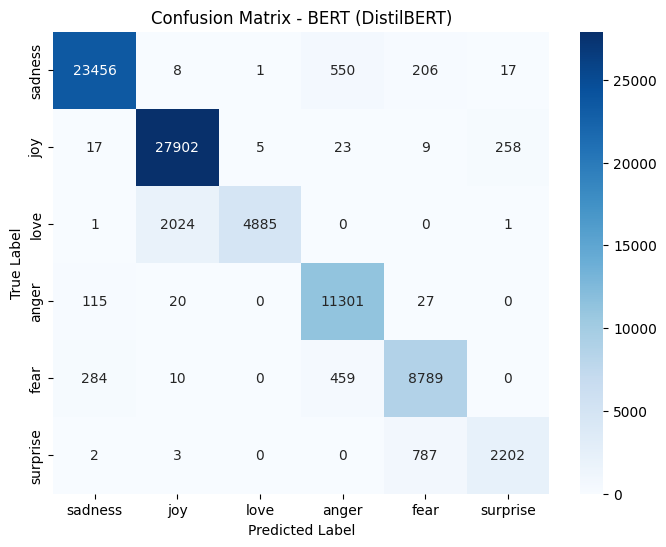

In [ ]:
print("Accuracy:", accuracy_score(true_labels, preds))
print(classification_report(true_labels, preds, zero_division=0))

# Create confusion matrix
cm = confusion_matrix(true_labels, preds)

# Emotion names (change according to your dataset mapping)
labels = ['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']

# Plot
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=labels,
    yticklabels=labels
)

plt.title('Confusion Matrix - BERT (DistilBERT)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [ ]:
output_model_dir = "./saved_streamlit_model"

model.save_pretrained(output_model_dir)
tokenizer.save_pretrained(output_model_dir)

print(f"\nModel and tokenizer successfully saved to '{output_model_dir}'!")
print("You can now load this folder directly into your Streamlit application.")